In [52]:
# Librerias
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.metrics import roc_auc_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Rf

In [53]:
# Carga de métricas de train y test
train = pd.read_csv("../data/masks/train/metricas_train.csv")
test = pd.read_csv("../data/masks/test/metricas_test.csv")

print(train.shape, test.shape)


(11879, 8) (2000, 8)


In [54]:
# Variables de entrada (características)
X_train = train[['area', 'perimetro', 'circularidad', 'simetria_vertical', 'simetria_horizontal']]
X_test  = test[['area', 'perimetro', 'circularidad', 'simetria_vertical', 'simetria_horizontal']]

# Variable objetivo
y_train = train['clase'].map({'Benign': 0, 'Malignant': 1})
y_test  = test['clase'].map({'Benign': 0, 'Malignant': 1})

In [55]:
rf = RandomForestClassifier(
    n_estimators=400,     # número de árboles
    max_depth=10,       # profundidad automática
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=400, n_jobs=-1,
                       random_state=42)

Accuracy en test: 0.7195


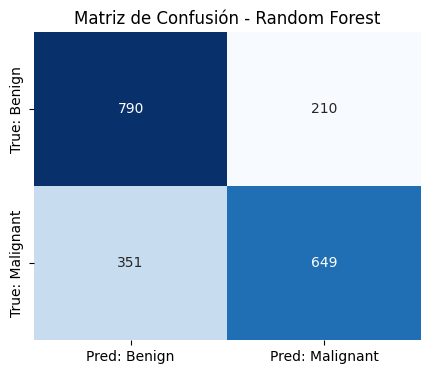


 Reporte de clasificación:
              precision    recall  f1-score   support

      Benign       0.69      0.79      0.74      1000
   Malignant       0.76      0.65      0.70      1000

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



In [56]:
y_pred = rf.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Benign', 'Pred: Malignant'],
            yticklabels=['True: Benign', 'True: Malignant'])
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("")
plt.ylabel("")
plt.show()
print("\n Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))


## Sobreajuste

In [57]:
r2_train = rf.score(X_train, y_train)
r2_test  = rf.score(X_test, y_test)
print(r2_train, r2_test)

0.8027611751830962 0.7195


## Conclusiones

Estas características se calculan a partir de la máscara segmentada del lunar (región blanca) y describen su forma, tamaño y simetría. Cada métrica aporta una dimensión distinta de información estructural al modelo.

| Métrica | Descripción | Unidad / Rango | Interpretación esperada |
|---------|-------------|----------------|-------------------------|
| Área | Número total de píxeles blancos que conforman la lesión. | Píxeles (valor absoluto, depende del tamaño de la imagen). | Lesiones más grandes suelen tener mayor riesgo de malignidad. |
| Perímetro | Longitud del contorno principal del lunar. | Píxeles (longitud). | Bordes más irregulares producen perímetros más largos. |
| Circularidad | $C = \frac{4\pi \cdot \text{Área}}{\text{Perímetro}^2}$ | Escala 0 a 1. Valor 1 indica una forma perfectamente circular. | Cuanto menor el valor, más irregular es la forma (mayor sospecha). |
| Simetría vertical (simetria_v) | Mide la coincidencia entre las mitades izquierda y derecha de la lesión. | Escala 0 a 1. Valor 1 indica simetría perfecta. | Los lunares benignos suelen ser más simétricos verticalmente. |
| Simetría horizontal (simetria_h) | Coincidencia entre las mitades superior e inferior de la lesión. | Escala 0 a 1. Valor 1 indica simetría perfecta. | Refuerza el patrón de simetría global; menor valor sugiere irregularidad. |

**Integración en la Red Neuronal Convolucional (CNN)**

- La CNN procesa la imagen original (RGB o HSV) y genera un vector de características visuales (color, textura, bordes).
- En paralelo, las cinco métricas morfológicas se normalizan (por ejemplo, mediante `StandardScaler`) y se procesan por un bloque denso separado.
- Ambos vectores (visual + morfológico) se concatenan antes de la capa final de clasificación.